# Tour Time Analysis (Figures 4 & 5)

Reproduction and analysis of **Figures 4 and 5** of Nagatani (2006): the tour
times $\Delta T_1$ and $\Delta T_2$ of bus 1 and bus 2 plotted against the
loading parameter $\Gamma$, for the asymmetric speedup case
$S_1 = 0.5$, $S_2 = 0.2$.

The **tour time** $\Delta T_i(m) = T_i(m+1) - T_i(m)$ is the time bus $i$ needs
to complete one full cycle (origin → destination → origin). Sweeping $\Gamma$
exposes three dynamical regimes:

| Region | $\Gamma$ | Tour-time behaviour |
|--------|----------|---------------------|
| Regular | $\Gamma \le 0.167$ | single value per $\Gamma$, grows smoothly |
| Periodic | just above $\Gamma_c$ | a few discrete branches |
| Chaotic | larger $\Gamma$ | scattered band of values |

Beyond reproducing Figures 4 and 5, this notebook locates the transition point,
plots the tour-time time series in each regime, and quantifies the asymmetry
between the two buses. Figure 4 shows the full range
$\Gamma \in [0, 2]$; Figure 5 zooms in near the first transition
$\Gamma_c \approx 0.167$.

## Mathematical Background

### Recurrence relation

The dimensionless arrival time $T_i(m)$ of bus $i$ at the origin on trip $m$ is
governed by the nonlinear map (Eq. 5 of Nagatani, 2006):

$$
T_i(m+1) = T_i(m)
          + \Gamma\bigl(T_i(m)-T_{i'}(m')\bigr)
          + \frac{1}{1 + S_i\bigl(T_i(m)-T_{i'}(m')\bigr)},
$$

where $T_{i'}(m')$ is the most recent arrival of the other bus before bus $i$,
$\Gamma$ is the **loading parameter** and $S_i$ is the **speedup parameter** of
bus $i$. The term $1/(1 + S_i\,\delta)$, with $\delta = T_i(m)-T_{i'}(m')$ the
headway gap to the preceding bus, is the running time of the next trip: a larger
$S_i$ lets the bus speed up more to absorb the loading delay.

### Tour time

The tour time of bus $i$ on trip $m$ is the interval between two successive
arrivals of the *same* bus at the origin:

$$ \Delta T_i(m) = T_i(m+1) - T_i(m). $$

Because the two buses overtake each other freely, the chronological arrival list
interleaves the buses; the tour time is obtained by filtering the list to one bus
and differencing consecutive arrival times. In the regular regime every trip
takes the same time, so $\Delta T_i$ collapses to a single value at each
$\Gamma$. Once the schedule turns periodic or chaotic, $\Delta T_i$ takes many
values, producing a vertical spread in the scatter plot.

## Setup

The notebook imports `simulate_bus_system` from the project's `simulator`
package (located at `src/simulator/`). All numerical work uses **NumPy**;
plotting uses **Matplotlib**.

In [33]:
import sys, os

SRC = os.path.abspath(os.path.join(os.getcwd(), '..'))
if SRC not in sys.path:
    sys.path.append(SRC)

import numpy as np
import matplotlib.pyplot as plt

from simulator.simulation import simulate_bus_system

## Simulation Parameters

Both figures use the asymmetric speedup case $S_1 = 0.5$, $S_2 = 0.2$. For each
of `N_GAMMA` loading values in $[0, 2]$ the map is iterated for `NUM_TRIPS`
trips; only the steady-state window $900 \le m \le 1000$ is kept, discarding the
transient. The first transition reported by Nagatani sits at
$\Gamma_c \approx 0.167$.

`GAMMA_REGIMES` fixes one representative $\Gamma$ for each regime, used later to
inspect the tour-time time series.

In [34]:
T1_INITIAL = 1.0
T2_INITIAL = 2.5
S1, S2     = 0.5, 0.2
NUM_TRIPS  = 1000
TRIP_MIN   = 900
TRIP_MAX   = 1000

GAMMA_RANGE = (0.0, 2.0)
N_GAMMA     = 2000
GAMMA_C     = 0.167          # point 1: regular -> periodic transition
GAMMA_MIN1  = 0.333          # bus-1 fluctuation minimum (Nagatani)

GAMMA_REGIMES = {
    'Regular  ($\\Gamma=0.10$)':  0.10,
    'Periodic ($\\Gamma=0.20$)':  0.20,
    'Chaotic  ($\\Gamma=0.50$)':  0.50,
}

## Data Extraction

`tour_times` filters the chronological arrival list to a single bus inside the
steady-state window and differences consecutive arrival times to obtain
$\Delta T_i$. `tour_series` keeps the trip index alongside each value so the
tour time can be plotted against $m$. `sweep_tour_times` repeats the extraction
across the $\Gamma$ grid, returning flat $(\Gamma, \Delta T)$ scatter
coordinates for each bus.

In [35]:
def tour_times(arrival_time, bus_id, trip_min, trip_max):
    """Tour times Delta T of one bus inside the steady-state trip window."""
    arr = np.array([r[0] for r in arrival_time
                    if r[1] == bus_id and trip_min <= r[2] <= trip_max])
    return np.diff(arr) if arr.size > 1 else np.array([])


def tour_series(arrival_time, bus_id, trip_min, trip_max):
    """(trip index m, Delta T) of one bus, ordered by trip number."""
    rec = sorted((r[2], r[0]) for r in arrival_time
                 if r[1] == bus_id and trip_min <= r[2] <= trip_max)
    if len(rec) < 2:
        return np.array([]), np.array([])
    m   = np.array([t for t, _ in rec])
    arr = np.array([x for _, x in rec])
    return m[1:], np.diff(arr)


def sweep_tour_times(gammas):
    """Flat (gamma, Delta T) scatter coordinates for bus 1 and bus 2."""
    g1, dt1, g2, dt2 = [], [], [], []
    for g in gammas:
        at = simulate_bus_system(T1_INITIAL, T2_INITIAL, g, S1, S2, NUM_TRIPS)
        t1 = tour_times(at, 1, TRIP_MIN, TRIP_MAX)
        t2 = tour_times(at, 2, TRIP_MIN, TRIP_MAX)
        g1.extend([g] * t1.size); dt1.extend(t1)
        g2.extend([g] * t2.size); dt2.extend(t2)
    return (np.array(g1), np.array(dt1)), (np.array(g2), np.array(dt2))


print('Running gamma sweep ...')
GAMMAS = np.linspace(*GAMMA_RANGE, N_GAMMA)
BUS1, BUS2 = sweep_tour_times(GAMMAS)
print(f'  bus 1: {BUS1[0].size} points   bus 2: {BUS2[0].size} points')

Running gamma sweep ...
  bus 1: 200000 points   bus 2: 200000 points


## Identifying the Dynamical Regimes

We count the number of **distinct** steady-state tour-time values (within a
tolerance) at one $\Gamma$ in each regime. A single value means regular motion;
a small finite count means a periodic orbit; a large count means chaos. This
locates the onset of fluctuations just above $\Gamma_c \approx 0.167$.

In [36]:
def count_distinct(values, tol=1e-4):
    """Number of distinct values up to an absolute tolerance."""
    uniq = []
    for v in values:
        if not any(abs(v - u) < tol for u in uniq):
            uniq.append(float(v))
    return len(uniq)


print(f'{"gamma":>6} | {"distinct dT1":>12} | {"distinct dT2":>12} | regime')
print('-' * 56)
for g in (0.10, 0.20, 0.50):
    at = simulate_bus_system(T1_INITIAL, T2_INITIAL, g, S1, S2, NUM_TRIPS)
    n1 = count_distinct(tour_times(at, 1, TRIP_MIN, TRIP_MAX))
    n2 = count_distinct(tour_times(at, 2, TRIP_MIN, TRIP_MAX))
    regime = ('regular' if max(n1, n2) <= 1 else
              'periodic' if max(n1, n2) <= 30 else 'chaotic')
    print(f'{g:6.2f} | {n1:12d} | {n2:12d} | {regime}')

 gamma | distinct dT1 | distinct dT2 | regime
--------------------------------------------------------
  0.10 |            1 |            1 | regular
  0.20 |           11 |           10 | periodic
  0.50 |           74 |           94 | chaotic


## Figure 4 — Tour time over the full loading range

Each panel is a scatter of $\Delta T_i$ against $\Gamma$. Below $\Gamma_c$ the
points lie on a single rising curve (regular schedule). Above $\Gamma_c$ the
spread opens up as the schedule turns periodic and then chaotic.

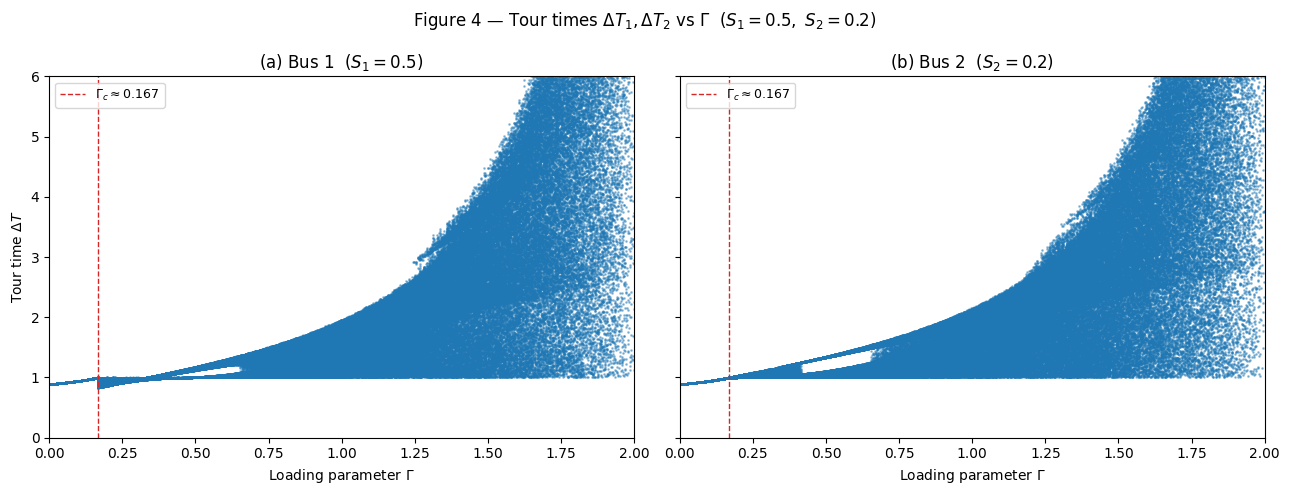

In [37]:
def plot_tour_panels(busdata, titles, xlim, ylim, suptitle):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
    for ax, (g, dt), title in zip(axes, busdata, titles):
        ax.scatter(g, dt, s=1, alpha=0.4, color='tab:blue')
        ax.axvline(GAMMA_C, color='tab:red', ls='--', lw=1,
                   label=r'$\Gamma_c \approx 0.167$')
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_xlabel(r'Loading parameter $\Gamma$')
        ax.set_title(title)
        ax.legend(loc='upper left', fontsize=9)
    axes[0].set_ylabel(r'Tour time $\Delta T$')
    fig.suptitle(suptitle)
    fig.tight_layout()
    return fig


fig4 = plot_tour_panels(
    [BUS1, BUS2],
    [r'(a) Bus 1  ($S_1 = 0.5$)', r'(b) Bus 2  ($S_2 = 0.2$)'],
    xlim=(0, 2), ylim=(0, 6),
    suptitle=r'Figure 4 — Tour times $\Delta T_1, \Delta T_2$ vs $\Gamma$'
             r'  ($S_1 = 0.5,\ S_2 = 0.2$)',
)
fig4.savefig('figure4_tour_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 5 — Zoom on the first transition

Restricting to $\Gamma \in [0, 0.5]$ and $\Delta T \in [0.75, 1.5]$ exposes the
onset: the curve is single-valued and smoothly increasing up to
$\Gamma_c \approx 0.167$, then splits into discrete branches (periodic motion)
before broadening into a chaotic band. Bus 1, with the larger speedup
$S_1 = 0.5$, splits and spreads more strongly than bus 2.

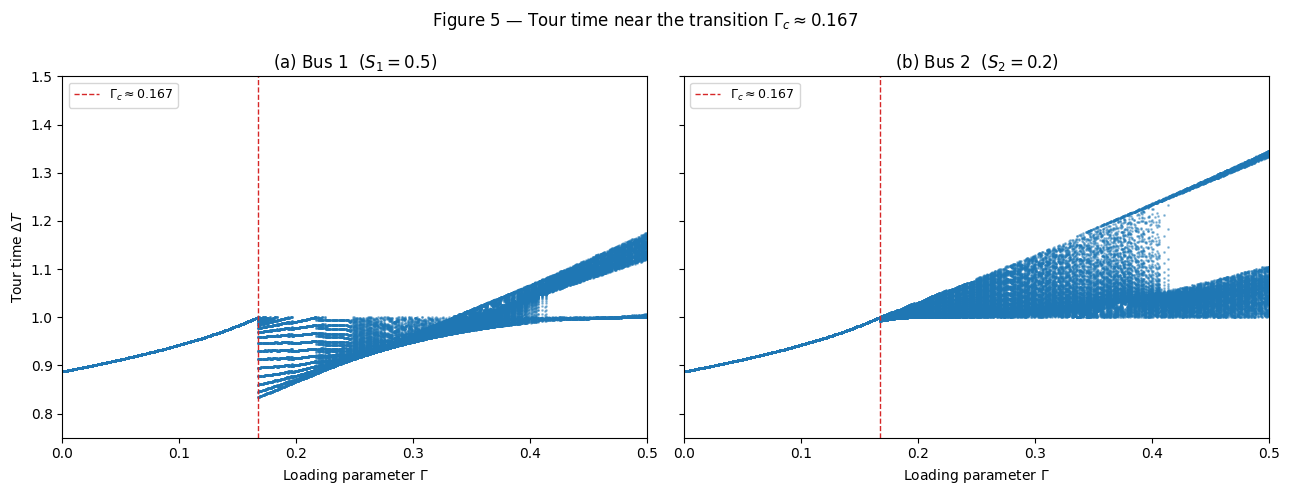

In [38]:
fig5 = plot_tour_panels(
    [BUS1, BUS2],
    [r'(a) Bus 1  ($S_1 = 0.5$)', r'(b) Bus 2  ($S_2 = 0.2$)'],
    xlim=(0, 0.5), ylim=(0.75, 1.5),
    suptitle=r'Figure 5 — Tour time near the transition $\Gamma_c \approx 0.167$',
)
fig5.savefig('figure5_tour_time_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

## Tour-Time Time Series Across Regimes

Plotting $\Delta T_1(m)$ and $\Delta T_2(m)$ against the trip index $m$ for one
$\Gamma$ in each regime shows *how* the tour time oscillates:

* **Regular ($\Gamma = 0.10$)**: both series are flat lines — every tour takes
  the same time.
* **Periodic ($\Gamma = 0.20$)**: the series repeat a fixed, finite pattern.
* **Chaotic ($\Gamma = 0.50$)**: both series fluctuate irregularly with no
  repeating pattern; here bus 2 develops the taller spikes while bus 1 stays
  nearer its mean — the two buses destabilise *differently*, not equally.

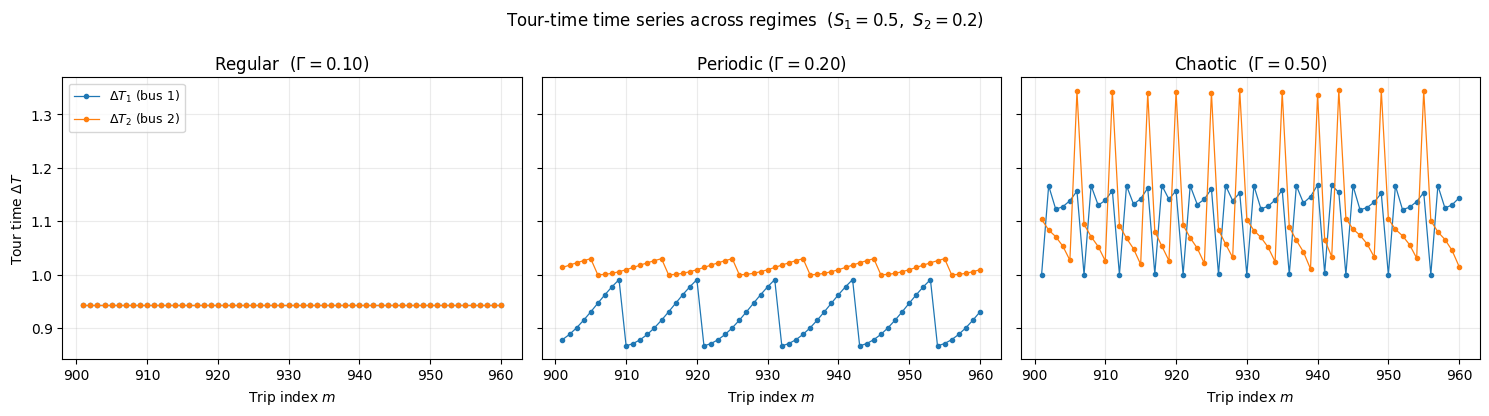

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
n_show = 60   # steady-state trips to display

for ax, (label, g) in zip(axes, GAMMA_REGIMES.items()):
    at = simulate_bus_system(T1_INITIAL, T2_INITIAL, g, S1, S2, NUM_TRIPS)
    m1, d1 = tour_series(at, 1, TRIP_MIN, TRIP_MAX)
    m2, d2 = tour_series(at, 2, TRIP_MIN, TRIP_MAX)
    ax.plot(m1[:n_show], d1[:n_show], '-o', ms=3, lw=0.9,
            color='tab:blue',   label=r'$\Delta T_1$ (bus 1)')
    ax.plot(m2[:n_show], d2[:n_show], '-o', ms=3, lw=0.9,
            color='tab:orange', label=r'$\Delta T_2$ (bus 2)')
    ax.set_title(label)
    ax.set_xlabel('Trip index $m$')
    ax.grid(alpha=0.25)

axes[0].set_ylabel(r'Tour time $\Delta T$')
axes[0].legend(loc='upper left', fontsize=9)
fig.suptitle(r'Tour-time time series across regimes  ($S_1=0.5,\ S_2=0.2$)')
fig.tight_layout()
plt.show()

## Quantifying the Asymmetry: Band Width

A simple, visual way to measure the asymmetry is the **band width** of the
tour-time scatter at each $\Gamma$ — literally the vertical thickness of the
cloud of points seen in Figures 4 and 5:

$$ \text{band width}_i(\Gamma) = \max \Delta T_i - \min \Delta T_i, $$

taken over the steady-state window. It is **zero while the schedule is regular**
(a single value) and grows once the tour time spreads out. Plotting it as a
curve makes the asymmetry obvious at a glance:

* **Right after $\Gamma_c = 0.167$**, bus 1's band jumps wide open while bus 2's
  is still almost a line — bus 1 destabilises first.
* **Bus 1's band then narrows**, reaching a minimum near $\Gamma = 0.333$, and
  widens again afterwards (non-monotonic).
* **Bus 2's band widens steadily** and overtakes bus 1 — the two curves cross.

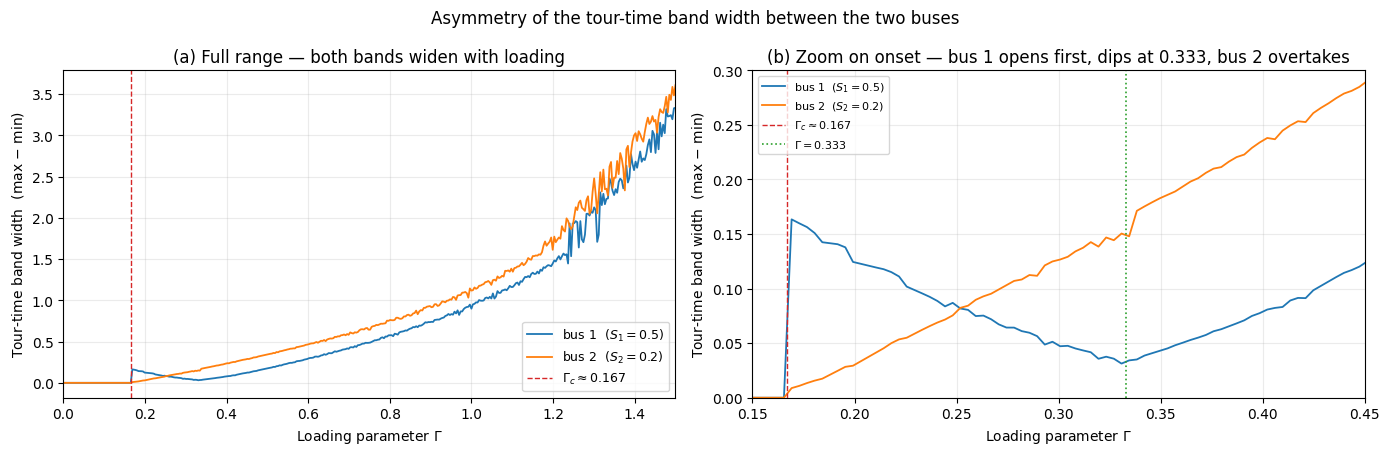

In [40]:
def tour_band_sweep(gammas):
    """Band width (max - min) of each bus's tour time vs gamma."""
    b1, b2 = [], []
    for g in gammas:
        at = simulate_bus_system(T1_INITIAL, T2_INITIAL, g, S1, S2, NUM_TRIPS)
        t1 = tour_times(at, 1, TRIP_MIN, TRIP_MAX)
        t2 = tour_times(at, 2, TRIP_MIN, TRIP_MAX)
        b1.append(t1.max() - t1.min() if t1.size else 0.0)
        b2.append(t2.max() - t2.min() if t2.size else 0.0)
    return np.array(b1), np.array(b2)


G_BAND = np.linspace(0.0, 1.5, 400)
BAND1, BAND2 = tour_band_sweep(G_BAND)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax in axes:
    ax.plot(G_BAND, BAND1, lw=1.3, color='tab:blue',   label=r'bus 1  ($S_1=0.5$)')
    ax.plot(G_BAND, BAND2, lw=1.3, color='tab:orange', label=r'bus 2  ($S_2=0.2$)')
    ax.axvline(GAMMA_C, color='tab:red', ls='--', lw=1, label=r'$\Gamma_c \approx 0.167$')
    ax.set_xlabel(r'Loading parameter $\Gamma$')
    ax.set_ylabel(r'Tour-time band width  (max $-$ min)')
    ax.grid(alpha=0.25)

axes[0].set_xlim(0, 1.5)
axes[0].set_title('(a) Full range — both bands widen with loading')
axes[0].legend(fontsize=9)

axes[1].axvline(GAMMA_MIN1, color='tab:green', ls=':', lw=1.2,
                label=r'$\Gamma = 0.333$')
axes[1].set_xlim(0.15, 0.45)
axes[1].set_ylim(0, 0.30)
axes[1].set_title('(b) Zoom on onset — bus 1 opens first, dips at 0.333, bus 2 overtakes')
axes[1].legend(fontsize=8, loc='upper left')

fig.suptitle('Asymmetry of the tour-time band width between the two buses')
fig.tight_layout()
plt.show()

## Explanation of Figures 4 and 5

### How speedup shapes the tour time

The tour time of a bus is $\Delta T_i = \Gamma\,\delta + 1/(1 + S_i\,\delta)$,
where $\delta$ is the headway gap to the bus ahead. It contains two opposing
effects:

- **Loading (destabilising):** a larger gap $\delta$ has collected more waiting
  passengers, so the loading term $\Gamma\,\delta$ lengthens the trip and the bus
  falls further behind. Left unchecked, the bus is eventually **overtaken** by
  the other, the bus order flips, and the headway — hence the tour time — jumps
  abruptly.
- **Speedup (stabilising):** the running term $1/(1 + S_i\,\delta)$ **shrinks** as
  $\delta$ grows, so a late bus runs faster and pulls its tour time back. A larger
  $S_i$ gives a stronger restoring pull.

For small $\Gamma$ the speedup wins: both buses converge to a constant tour time
(the map's fixed point) that grows smoothly with $\Gamma$ — the single rising
curve below $\Gamma_c$ in Figure 5.

### Why larger Γ produces fluctuations

Raising $\Gamma$ strengthens the destabilising loading term. In sequence:

1. **$\Gamma < 0.167$ — regular:** stable fixed point, constant tour time, zero
   spread.
2. **$\Gamma = 0.167$ — regular → periodic:** the fixed point loses stability and
   the tour time settles onto a finite cycle. At $\Gamma = 0.2$ it visits 11
   distinct values (period-11).
3. **larger $\Gamma$ — period-adding then chaos:** the cycle grows through a
   cascade and then fills a continuous band; by $\Gamma = 0.5$ the tour time
   visits dozens of values and never repeats — **deterministic chaos with no
   random noise**. This widening band is what fills Figure 4.
4. **$\Gamma \to 2$ — divergence:** the loading term dominates completely, the
   delay accumulates without bound, and the tour time diverges — the schedule
   collapses.

### Why the two buses behave differently

Both buses obey the same map, but their speedup parameters differ
($S_1 = 0.5 > S_2 = 0.2$), so the stabilising term is stronger for bus 1. This
breaks the symmetry — though not by making one bus fluctuate more everywhere:

- **At the onset ($\Gamma$ just above $0.167$)** bus 1 is the *first* to leave the
  regular regime: its band jumps wide open while bus 2's is still almost a line.
- **Bus 1's spread is non-monotonic:** it narrows to a minimum near
  $\Gamma = 0.333$, then widens again.
- **Bus 2's spread grows steadily** and overtakes bus 1 — the two band-width
  curves cross, and in the chaotic time series bus 2 carries the taller spikes.

So the two buses take *different routes into chaos*: bus 1 destabilises earlier,
while bus 2 oscillates more strongly deep in the chaotic region.

### Takeaways

- Below the threshold $\Gamma_c \approx 0.167$, speedup keeps both tour times
  constant — the buses run on a predictable schedule.
- Above it the tour time goes periodic → chaotic → divergent; the irregularity is
  **deterministic chaos** from boarding and free overtaking, not randomness.
- Unequal speedup ($S_1 \ne S_2$) makes the two buses destabilise differently —
  the asymmetry seen in Figures 4 and 5.